In [20]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris


In [21]:
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [22]:
df = df.drop(['petal length (cm)','petal width (cm)'],axis='columns')

In [23]:
df

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


Text(0, 0.5, 'width')

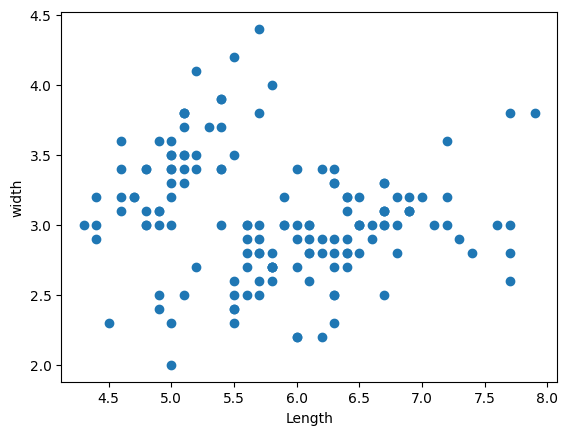

In [24]:
plt.scatter(df['sepal length (cm)'],df['sepal width (cm)'])
plt.xlabel('Length')
plt.ylabel('width')


In [25]:
km =KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['sepal length (cm)','sepal width (cm)']])
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [26]:
df['Cluster'] = y_predicted
df.head()

,sepal length (cm),sepal width (cm),Cluster
0,5.1,3.5,1
1,4.9,3.0,1
2,4.7,3.2,1
3,4.6,3.1,1
4,5.0,3.6,1


In [27]:
df['target'] = iris.target
df

,sepal length (cm),sepal width (cm),Cluster,target
0,5.1,3.5,1,0
1,4.9,3.0,1,0
2,4.7,3.2,1,0
3,4.6,3.1,1,0
4,5.0,3.6,1,0
...,...,...,...,...
145,6.7,3.0,2,2
146,6.3,2.5,0,2
147,6.5,3.0,2,2
148,6.2,3.4,2,2


In [28]:
km.cluster_centers_

array([[5.8       , 2.7       ],
       [5.00392157, 3.40980392],
       [6.82391304, 3.07826087]])

Text(0, 0.5, 'Width')

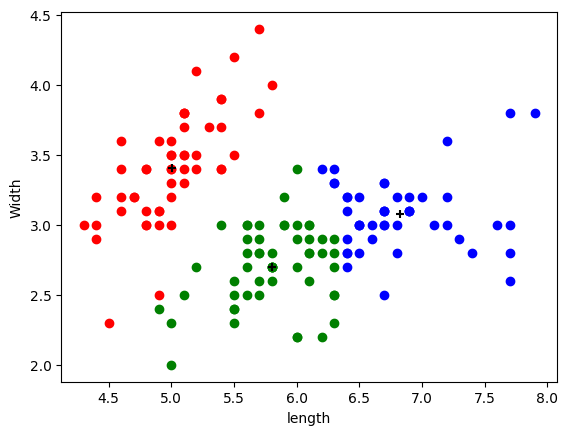

In [29]:
df1 = df[df['Cluster'] == 0]
df2 = df[df['Cluster'] == 1]
df3 = df[df['Cluster'] == 2]

plt.scatter(df1['sepal length (cm)'],df1['sepal width (cm)'],color='green')
plt.scatter(df2['sepal length (cm)'],df2['sepal width (cm)'],color='red')
plt.scatter(df3['sepal length (cm)'],df3['sepal width (cm)'],color='blue')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='black',marker='+',label='centroid')
plt.xlabel('length')
plt.ylabel('Width')



In [30]:
scaler = MinMaxScaler()
scaler.fit(df[['sepal length (cm)']])
df['sepal length (cm)'] = scaler.transform(df[['sepal length (cm)']])

scaler.fit(df[['sepal width (cm)']])
df['sepal width (cm)'] = scaler.transform(df[['sepal width (cm)']])
df = df.drop(['Cluster', 'target'], axis='columns')
df

,sepal length (cm),sepal width (cm)
0,0.222222,0.625000
1,0.166667,0.416667
2,0.111111,0.500000
3,0.083333,0.458333
4,0.194444,0.666667
...,...,...
145,0.666667,0.416667
146,0.555556,0.208333
147,0.611111,0.416667
148,0.527778,0.583333


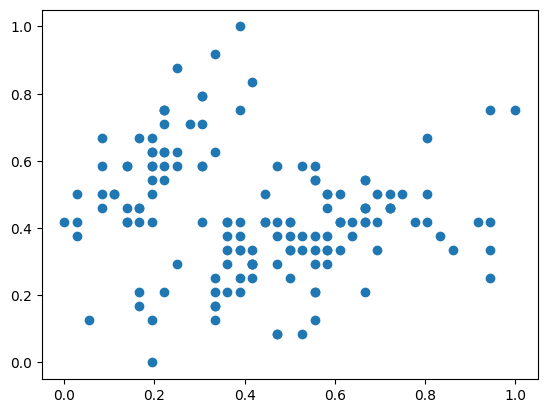

In [31]:
plt.scatter(df['sepal length (cm)'],df['sepal width (cm)'])

In [32]:
km1 = KMeans(n_clusters=3)
y_predicted1 = km1.fit_predict(df[['sepal length (cm)','sepal width (cm)']])
y_predicted1

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0], dtype=int32)

In [33]:
df['Cluster'] = y_predicted1
df

,sepal length (cm),sepal width (cm),Cluster
0,0.222222,0.625000,2
1,0.166667,0.416667,2
2,0.111111,0.500000,2
3,0.083333,0.458333,2
4,0.194444,0.666667,2
...,...,...,...
145,0.666667,0.416667,1
146,0.555556,0.208333,0
147,0.611111,0.416667,1
148,0.527778,0.583333,1


In [34]:
km1.cluster_centers_

array([[0.390625  , 0.26649306],
       [0.67557652, 0.44654088],
       [0.19897959, 0.60459184]])

Text(0, 0.5, 'Width')

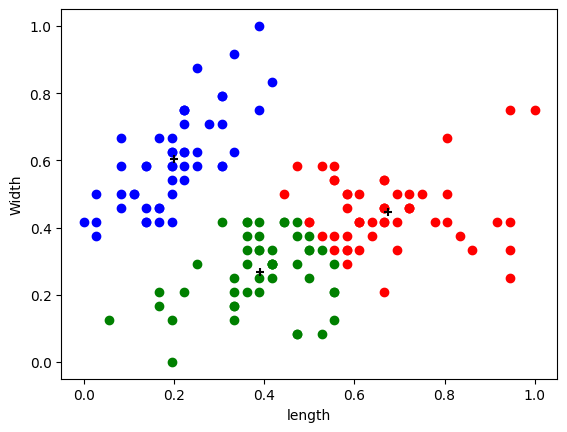

In [35]:
df4 = df[df['Cluster'] == 0]
df5 = df[df['Cluster'] == 1]
df6 = df[df['Cluster'] == 2]

plt.scatter(df4['sepal length (cm)'],df4['sepal width (cm)'],color='green')
plt.scatter(df5['sepal length (cm)'],df5['sepal width (cm)'],color='red')
plt.scatter(df6['sepal length (cm)'],df6['sepal width (cm)'],color='blue')
plt.scatter(km1.cluster_centers_[:,0],km1.cluster_centers_[:,1],color='black',marker='+',label='centroid')
plt.xlabel('length')
plt.ylabel('Width')


In [36]:
sse = []
k_range = range(1,10)
for k in k_range:
    km1 = KMeans(n_clusters=k)
    km1.fit(df[['sepal length (cm)','sepal width (cm)']])
    sse.append(km1.inertia_)


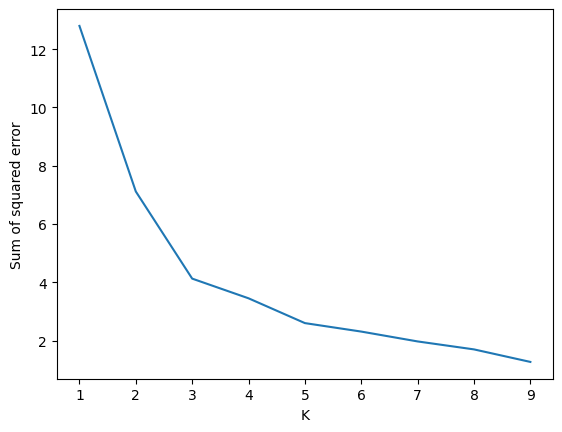

In [38]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_range,sse)